# F4 · Métricas de posición partidaria y afinidad entre pares

## Objetivo
Presentar y visualizar los resultados ya generados por los módulos de F4 para:

1. **Posición partidaria**: posición por partido y votación (`b_pj`) y perfil partidario (`P_p`).
2. **Afinidad entre pares**: co-votos, acuerdo nominal y distancia de Hamming.
3. **Sensibilidad**: efecto de retirar una votación sobre `P_p` y sobre la afinidad.

## Entradas y organización
Se usan las salidas de `posicion_partidos.py` (`posicion_partidaria.csv`), `afinidad.py`
(`afinidad_diputados.csv`, `matriz_hamming.csv`, `hamming_partidos.csv`), `sensibilidad.py` (`sensibilidad.csv`), la
matriz nominal, la afiliación por votación y el universo por método de B04. El notebook **no
reimplementa las fórmulas**: lee esas tablas, comprueba que coincidan con el universo
registrado (y la Hamming entre partidos con su recálculo por `afinidad.py`) y escribe solo sus figuras, en `F4/figures/partidos_afinidad/`.

### Cautelas de interpretación
- `P_p` representa una **posición relativa dentro del corpus analizado**; no se interpreta como etiqueta ideológica.
- La dispersión de `d1` dentro de un partido es descriptiva y **no equivale a cohesión**.
- La afinidad solo se calcula sobre **co-votos**; dos celdas sin decisión registrada no cuentan como acuerdo.
- La cobertura observada no se interpreta como asistencia: no existe un padrón verificable.
- La posición partidaria agrega a IND como grupo; su tratamiento está pendiente de decisión (A03-012).

In [1]:
import json
import platform
import subprocess
import sys
import tomllib
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

raiz = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'pyproject.toml').is_file() and (p / 'F4/src/analisis').is_dir()), None)
if raiz is None:
    raise FileNotFoundError('Ejecuta el notebook dentro del repositorio.')
if str(raiz) not in sys.path:
    sys.path.insert(0, str(raiz))
from F4.src.analisis import visualizacion as vis  # noqa: E402
from F4.src.analisis.afinidad import cargar_matriz_nominal, hamming_entre_partidos  # noqa: E402

rutas = {
    'config': raiz / 'F4/config/analisis.toml',
    'manifiesto': raiz / 'F4/data/reports/manifiesto_corte.json',
    'posicion': raiz / 'F4/data/results/partidos/posicion_partidaria.csv',
    'afinidad': raiz / 'F4/data/results/pares/afinidad_diputados.csv',
    'hamming': raiz / 'F4/data/results/pares/matriz_hamming.csv',
    'hamming_partidos': raiz / 'F4/data/results/pares/hamming_partidos.csv',
    'sensibilidad': raiz / 'F4/data/reports/sensibilidad.csv',
    'universo': raiz / 'F4/data/reports/universo_por_metodo.csv',
    'nominal': raiz / 'F4/data/processed/matriz_nominal.csv',
    'afiliacion': raiz / 'F4/data/processed/afiliacion_por_votacion.csv',
    'votos': raiz / 'F4/data/processed/votos_codificados.csv',
}
for nombre, ruta in rutas.items():
    if not ruta.is_file() or ruta.stat().st_size == 0:
        raise FileNotFoundError(f'Entrada ausente o vacía: {ruta.relative_to(raiz)}')
FIGURAS = raiz / 'F4/figures/partidos_afinidad'
FIGURAS.mkdir(parents=True, exist_ok=True)

with rutas['config'].open('rb') as archivo:
    config = tomllib.load(archivo)
manifiesto = json.loads(rutas['manifiesto'].read_text(encoding='utf-8'))
# Semilla del protocolo: solo controla el desplazamiento visual de puntos.
SEMILLA = config['reproducibilidad']['semilla']

# Convenciones visuales comunes (F4/src/analisis/visualizacion.py).
vis.aplicar_estilo()
pd.set_option('display.max_columns', 50)
figuras_generadas = []


def guardar(fig, nombre):
    vis.guardar(fig, FIGURAS / nombre, figuras_generadas)


def lado(valor):
    """Lado del eje B-Call: valores negativos del lado L y positivos del lado R."""
    return 'L' if valor < 0 else 'R'

## 1. Carga y validación de resultados
Se cargan las tablas finales de los módulos y se separan las filas de posición por
partido × votación de las filas de resumen por partido. Los conteos se comparan con
`universo_por_metodo.csv` (B04).

In [2]:
posicion = pd.read_csv(rutas['posicion'])
afinidad = pd.read_csv(rutas['afinidad'])
matriz_hamming = pd.read_csv(rutas['hamming'], index_col='diputado_id')
sensibilidad = pd.read_csv(rutas['sensibilidad'])
votos = pd.read_csv(rutas['votos'])
universo = pd.read_csv(rutas['universo']).set_index('metodo')

partido_votacion = posicion.loc[posicion['nivel'].eq('partido_votacion')].copy()
partidos = posicion.loc[posicion['nivel'].eq('partido')].copy()

assert matriz_hamming.shape[0] == matriz_hamming.shape[1]
assert {'P_p', 'n_votaciones', 'mediana_d1', 'iqr_d1'}.issubset(partidos.columns)
assert {'acuerdo', 'hamming', 'n_covotos', 'incluido'}.issubset(afinidad.columns)

controles = pd.DataFrame([
    ('posicion_partido_votacion', len(partido_votacion),
     int(partido_votacion['incluido'].fillna(False).astype(bool).sum())),
    ('posicion_partidaria_P_p', len(partidos), int(partidos['P_p'].notna().sum())),
    ('afinidad_pares', len(afinidad), int(afinidad['incluido'].fillna(False).astype(bool).sum())),
], columns=['metodo', 'n_corpus', 'n_incluidos']).set_index('metodo')
controles['coincide_con_universo'] = (
    controles[['n_corpus', 'n_incluidos']]
    .eq(universo.loc[controles.index, ['n_corpus', 'n_incluidos']]).all(axis=1))
display(controles)
print('Coincide con universo_por_metodo.csv:', bool(controles['coincide_con_universo'].all()))
assert controles['coincide_con_universo'].all()

,n_corpus,n_incluidos,coincide_con_universo
metodo,,,
posicion_partido_votacion,259,194,True
posicion_partidaria_P_p,22,15,True
afinidad_pares,11325,9141,True


Coincide con universo_por_metodo.csv: True


## 2. Posición partidaria

`P_p` resume la posición relativa del partido dando igual peso a cada votación válida. La tabla mantiene `n_votaciones` como denominador efectivo y la mediana/IQR de `d1` como descripción de la distribución de sus integrantes.

Los partidos sin suficientes votaciones válidas permanecen en la tabla con `P_p = NA` y su motivo de no estimabilidad.

In [3]:
columnas_partido = [
    "partido_id", "partido_nombre", "partido_alias",
    "P_p", "n_votaciones", "mediana_d1", "iqr_d1",
    "razon_NA", "estado",
]
tabla_partidos = partidos[columnas_partido].copy()
tabla_partidos = tabla_partidos.sort_values(["P_p", "partido_alias"], na_position="last")
display(tabla_partidos)

,partido_id,partido_nombre,partido_alias,P_p,n_votaciones,mediana_d1,iqr_d1,razon_NA,estado
278,DC,Partido Demócrata Cristiano,DC,-0.726106,13.0,-0.726106,0.000000,NaN,DESCRIPTIVO_SIN_PADRON
267,PAH,Partido Acción Humanista,PAH,-0.726106,13.0,-0.726106,0.000000,NaN,DESCRIPTIVO_SIN_PADRON
264,PC,Partido Comunista,PC,-0.726106,13.0,-0.726106,0.000000,NaN,DESCRIPTIVO_SIN_PADRON
265,PL,Partido Liberal de Chile,PL,-0.726106,13.0,-0.726106,0.000000,NaN,DESCRIPTIVO_SIN_PADRON
270,PPD,Partido Por la Democracia,PPD,-0.726106,13.0,-0.726106,0.005699,NaN,DESCRIPTIVO_SIN_PADRON
259,PS,Partido Socialista,PS,-0.726106,13.0,-0.726106,0.011398,NaN,DESCRIPTIVO_SIN_PADRON
268,PCS,Partido Convergencia Social,PCS,-0.714709,12.0,-0.726106,0.005699,NaN,DESCRIPTIVO_SIN_PADRON
271,PR,Partido Radical de Chile,PR,-0.714709,12.0,-0.720407,0.005699,NaN,DESCRIPTIVO_SIN_PADRON
274,RD,Revolución Democrática,RD,-0.714709,12.0,-0.726106,0.002849,NaN,DESCRIPTIVO_SIN_PADRON
260,IND,Independientes,IND,-0.131459,13.0,-0.638218,1.959769,NaN,DESCRIPTIVO_SIN_PADRON


### 2.1. Perfil relativo por partido

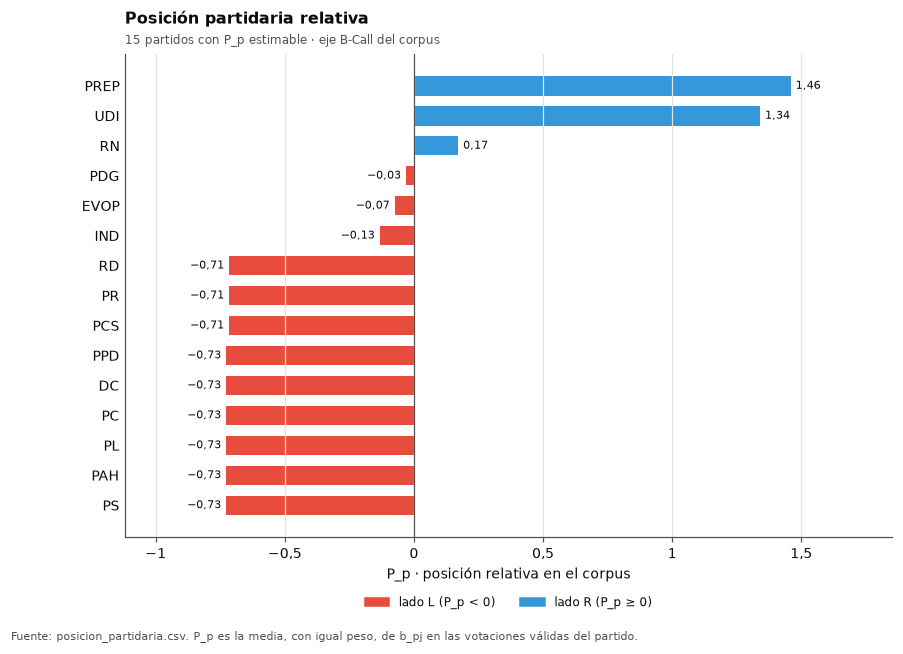

In [4]:
estimables = partidos.loc[partidos['P_p'].notna()].copy().sort_values('P_p')

fig, ax = plt.subplots(figsize=(9, max(4.5, 0.38 * len(estimables))))
colores = [vis.GRUPOS[lado(v)] for v in estimables['P_p']]
ax.barh(estimables['partido_alias'], estimables['P_p'], color=colores, height=0.65)
ax.axvline(0, color=vis.TEXTO_SECUNDARIO, linewidth=0.8)
for y, v in enumerate(estimables['P_p']):
    ax.text(v + (-0.02 if v < 0 else 0.02), y, vis.coma(v), va='center',
            ha='right' if v < 0 else 'left', fontsize=7.5, color=vis.TEXTO)
margen = 0.18 * (estimables['P_p'].max() - estimables['P_p'].min())
ax.set_xlim(estimables['P_p'].min() - margen, estimables['P_p'].max() + margen)
ax.set_xlabel('P_p · posición relativa en el corpus')
ax.tick_params(axis='y', length=0)
ax.grid(axis='x')
vis.formato_coma(ax, 'x')
vis.titulo(ax, 'Posición partidaria relativa',
           f'{len(estimables)} partidos con P_p estimable · eje B-Call del corpus')
vis.leyenda_inferior(ax, [vis.parche(vis.GRUPOS['L'], 'lado L (P_p < 0)'),
                          vis.parche(vis.GRUPOS['R'], 'lado R (P_p ≥ 0)')], ncol=2, y=-0.1)
vis.nota(fig, 'Fuente: posicion_partidaria.csv. P_p es la media, con igual peso, de b_pj en '
              'las votaciones válidas del partido.', y=-0.04)
guardar(fig, 'posicion_partidaria.png')
plt.show()

La figura ordena los valores de `P_p`. El color indica el lado del eje B-Call, con la
misma convención que el resto de F4: **rojo = lado L** (valores negativos) y **azul = lado R**
(valores positivos). El signo y la magnitud se interpretan únicamente respecto del eje
construido para este corpus; no constituyen una clasificación ideológica general.

### 2.2. Posición y heterogeneidad descriptiva de integrantes

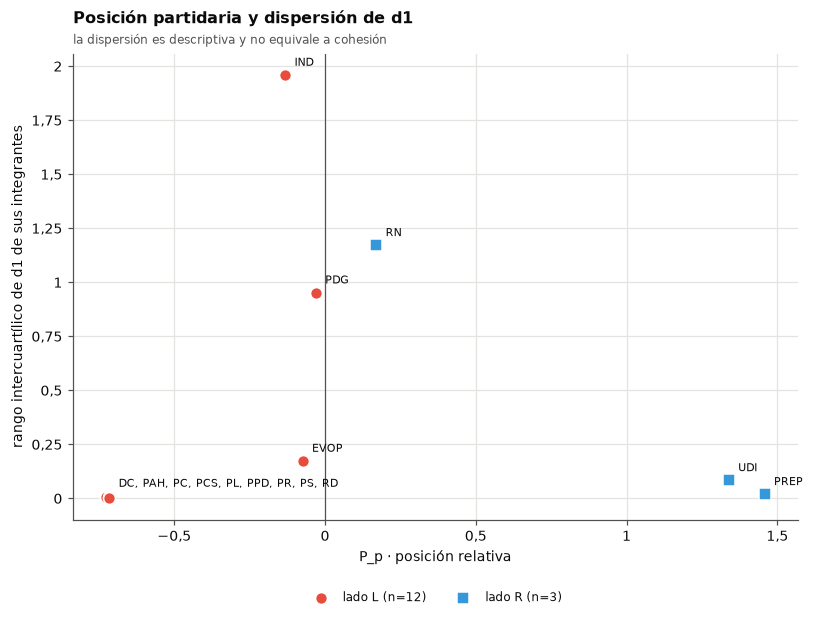

In [5]:
estimables_disp = estimables.loc[
    estimables['mediana_d1'].notna() & estimables['iqr_d1'].notna()].copy()

fig, ax = plt.subplots(figsize=(8.5, 5.5))
for grupo in ('L', 'R'):
    datos = estimables_disp[estimables_disp['P_p'].map(lado).eq(grupo)]
    ax.scatter(datos['P_p'], datos['iqr_d1'], s=60, color=vis.GRUPOS[grupo],
               marker=vis.MARCADORES_GRUPO[grupo], edgecolors='white', linewidths=1,
               label=f'lado {grupo} (n={len(datos)})', zorder=3)
# Un rótulo por zona: los partidos con posiciones casi iguales se listan juntos.
rotulos = estimables_disp.assign(x=estimables_disp['P_p'].round(1),
                                 y=estimables_disp['iqr_d1'].round(1))
for _, grupo in rotulos.groupby(['x', 'y']):
    ax.annotate(', '.join(sorted(grupo['partido_alias'])),
                (grupo['P_p'].max(), grupo['iqr_d1'].max()), xytext=(6, 6),
                textcoords='offset points', fontsize=7.5, color=vis.TEXTO)
ax.axvline(0, color=vis.TEXTO_SECUNDARIO, linewidth=0.8)
ax.set_xlabel('P_p · posición relativa')
ax.set_ylabel('rango intercuartílico de d1 de sus integrantes')
ax.grid(True)
vis.formato_coma(ax, 'x')
vis.formato_coma(ax, 'y')
vis.titulo(ax, 'Posición partidaria y dispersión de d1',
           'la dispersión es descriptiva y no equivale a cohesión')
vis.leyenda_inferior(ax, ncol=2, y=-0.13)
guardar(fig, 'posicion_partidaria_dispersion_d1.png')
plt.show()

El IQR de `d1` muestra dispersión interna de posiciones individuales. No sustituye los índices de cohesión partidaria (AI, Rice o entropía), que se analizan por separado.

### 2.3. Posición por partido × votación

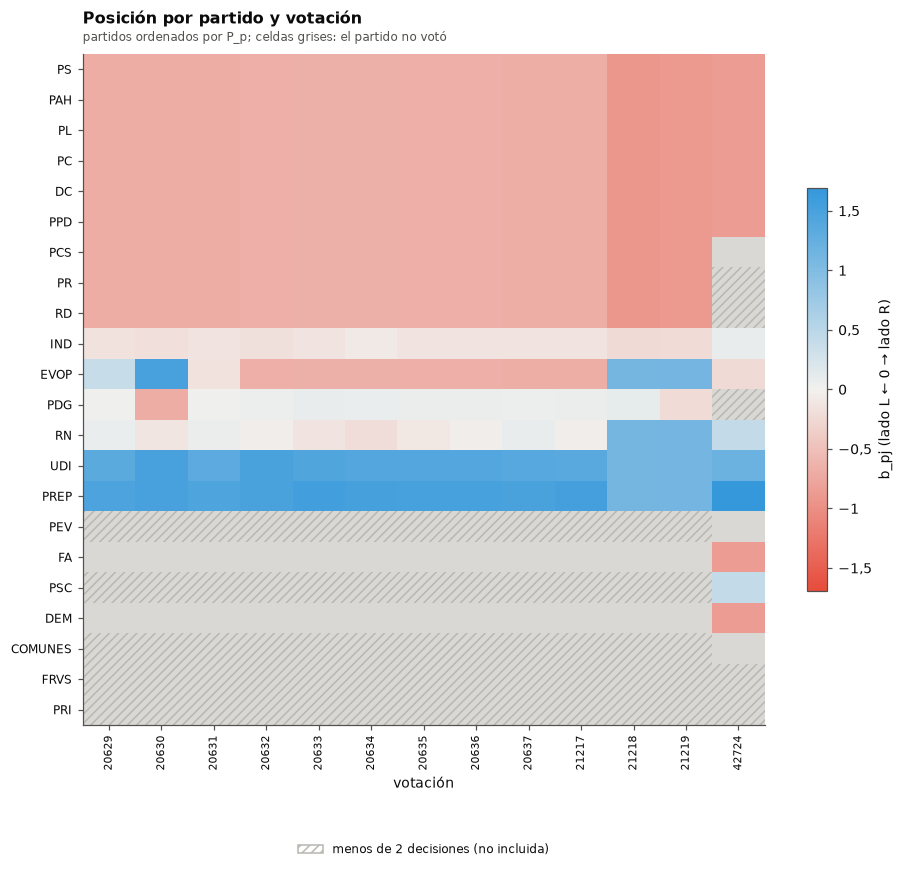

In [6]:
orden = (partidos.set_index('partido_alias')['P_p'].sort_values(na_position='last').index)
b_pj = partido_votacion.pivot_table(index='partido_alias', columns='votacion_id',
                                    values='b_pj', aggfunc='first')
incluida = partido_votacion.pivot_table(index='partido_alias', columns='votacion_id',
                                        values='incluido', aggfunc='first')
filas = [p for p in orden if p in b_pj.index]
b_pj, incluida = b_pj.reindex(filas), incluida.reindex(filas).fillna(False).astype(bool)
valores = b_pj.where(incluida)

fig, ax = plt.subplots(figsize=(10, max(5, 0.36 * len(filas))))
imagen = ax.imshow(valores.to_numpy(dtype=float), aspect='auto', cmap=vis.DIVERGENTE_LR,
                   norm=vis.norma_simetrica(valores.to_numpy(dtype=float)))
for (i, j), v in np.ndenumerate(b_pj.to_numpy(dtype=float)):
    if pd.notna(v) and not incluida.iat[i, j]:
        ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, hatch='////',
                                   edgecolor=vis.RAYADO, lw=0))
ax.set_xticks(range(b_pj.shape[1]), [str(int(v)) for v in b_pj.columns], rotation=90,
              fontsize=7)
ax.set_yticks(range(len(filas)), filas, fontsize=8)
ax.set_xlabel('votación')
barra = fig.colorbar(imagen, ax=ax, shrink=0.6, label='b_pj (lado L ← 0 → lado R)')
vis.formato_coma(barra.ax, 'y')
vis.titulo(ax, 'Posición por partido y votación',
           'partidos ordenados por P_p; celdas grises: el partido no votó')
vis.leyenda_inferior(ax, [vis.parche('white', 'menos de 2 decisiones (no incluida)',
                                     edgecolor=vis.RAYADO, hatch='////')], ncol=1, y=-0.16)
guardar(fig, 'posicion_partido_votacion.png')
plt.show()

## 3. Afinidad entre pares
El análisis considera solo votaciones compartidas con decisión observada para ambos diputados:

- `acuerdo`: proporción de co-votos con la misma opción nominal.
- `hamming`: proporción de co-votos en que difieren (`1 − acuerdo`).
- `n_covotos`: denominador efectivo del par.
- `incluido`: indica si el par alcanza el mínimo metodológico de co-votos (`pares.min_covotos`).

La abstención es una categoría nominal propia. Los faltantes simultáneos no se consideran coincidencia.

In [7]:
resumen_afinidad = pd.Series({
    "pares_totales": len(afinidad),
    "pares_incluidos": int(afinidad["incluido"].fillna(False).sum()),
    "pares_sin_covotos": int(afinidad["n_covotos"].eq(0).sum()),
    "mediana_covotos_pares_incluidos": float(
        afinidad.loc[afinidad["incluido"].fillna(False), "n_covotos"].median()
    ),
    "mediana_acuerdo_pares_incluidos": float(
        afinidad.loc[afinidad["incluido"].fillna(False), "acuerdo"].median()
    ),
    "mediana_hamming_pares_incluidos": float(
        afinidad.loc[afinidad["incluido"].fillna(False), "hamming"].median()
    ),
})
display(resumen_afinidad)

pares_totales                      11325.000000
pares_incluidos                     9141.000000
pares_sin_covotos                    423.000000
mediana_covotos_pares_incluidos       14.000000
mediana_acuerdo_pares_incluidos        0.733333
mediana_hamming_pares_incluidos        0.266667
dtype: float64

### 3.1. Distribución del acuerdo

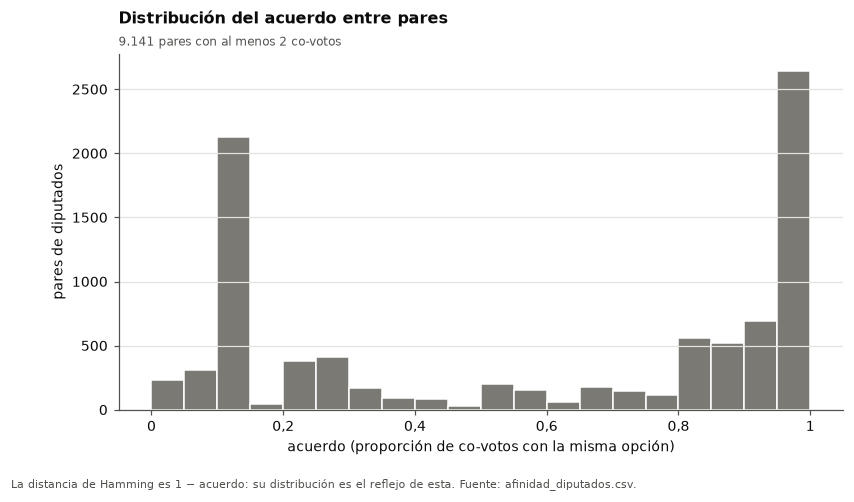

In [8]:
pares_validos = afinidad.loc[afinidad['incluido'].fillna(False).astype(bool)].copy()
for columna in ('n_covotos', 'acuerdo', 'hamming'):
    pares_validos[columna] = pd.to_numeric(pares_validos[columna], errors='coerce')

fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.hist(pares_validos['acuerdo'].dropna(), bins=np.linspace(0, 1, 21), color=vis.NEUTRO,
        edgecolor='white', linewidth=1)
ax.set_xlabel('acuerdo (proporción de co-votos con la misma opción)')
ax.set_ylabel('pares de diputados')
ax.grid(axis='y')
vis.formato_coma(ax, 'x')
vis.titulo(ax, 'Distribución del acuerdo entre pares',
           f'{len(pares_validos):,} pares con al menos '.replace(',', '.')
           + f"{config['pares']['min_covotos']} co-votos")
vis.nota(fig, 'La distancia de Hamming es 1 − acuerdo: su distribución es el reflejo de esta. '
              'Fuente: afinidad_diputados.csv.', y=-0.04)
guardar(fig, 'afinidad_distribucion.png')
plt.show()

### 3.2. Distancia según co-votos disponibles
Cada punto es un par (con un pequeño desplazamiento aleatorio para separar pares
repetidos, controlado por la semilla del protocolo). La línea muestra la mediana y la banda
el rango intercuartílico por número de co-votos. La línea de 10 co-votos es solo una
referencia visual: el mínimo del protocolo es `pares.min_covotos`.

,q25,mediana,q75,n_pares,pct_cero
n_covotos,,,,,
2,0.000,0.000,0.500,96,51.042
12,0.000,0.000,1.000,397,53.149
13,0.000,0.231,0.923,797,32.748
14,0.000,0.286,0.857,3291,30.356
15,0.067,0.267,0.867,4560,24.627


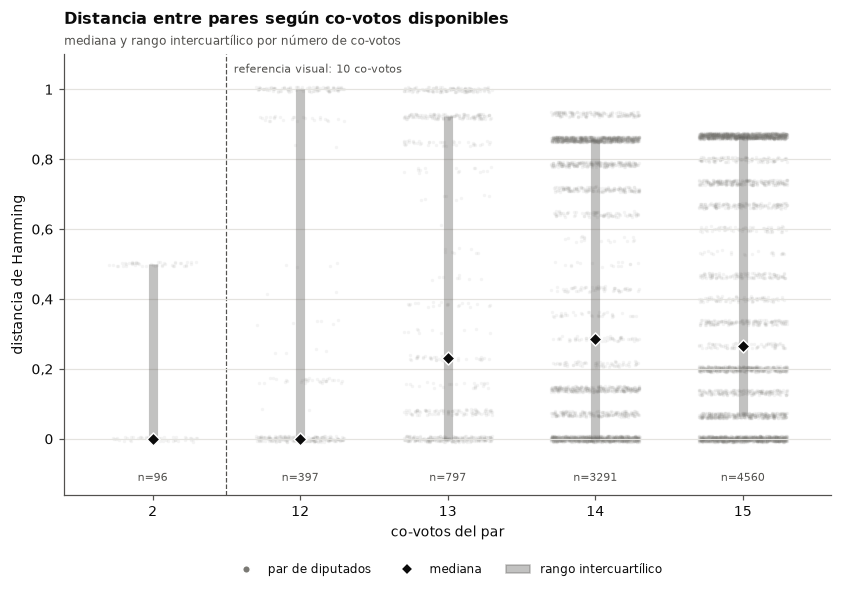

In [9]:
REFERENCIA_COVOTOS = config['pares']['referencia_grafica_covotos']
grupos = pares_validos.groupby('n_covotos')['hamming']
resumen_cov = pd.DataFrame({
    'q25': grupos.quantile(0.25), 'mediana': grupos.median(), 'q75': grupos.quantile(0.75),
    'n_pares': grupos.size(), 'pct_cero': grupos.apply(lambda s: (s == 0).mean() * 100),
}).sort_index()
display(resumen_cov.round(3))

# Los co-votos toman pocos valores: se ubican como categorías equiespaciadas.
categorias = list(resumen_cov.index)
posicion_cat = {n: i for i, n in enumerate(categorias)}
rng = np.random.default_rng(SEMILLA)
x = pares_validos['n_covotos'].map(posicion_cat) + rng.uniform(-0.3, 0.3, len(pares_validos))
y = pares_validos['hamming'] + rng.uniform(-0.008, 0.008, len(pares_validos))
fig, ax = plt.subplots(figsize=(9, 5.2))
ax.scatter(x, y, s=5, alpha=0.08, color=vis.NEUTRO, linewidths=0, zorder=1)
posiciones = np.arange(len(categorias))
ax.vlines(posiciones, resumen_cov['q25'], resumen_cov['q75'], color=vis.TEXTO_SECUNDARIO,
          lw=6, alpha=0.35, zorder=2)
ax.scatter(posiciones, resumen_cov['mediana'], marker='D', s=36, color=vis.TEXTO,
           edgecolors='white', linewidths=1, zorder=3)
for i, fila in enumerate(resumen_cov.itertuples()):
    ax.text(i, -0.12, f'n={fila.n_pares}', ha='center', fontsize=7,
            color=vis.TEXTO_SECUNDARIO)
debajo = sum(n < REFERENCIA_COVOTOS for n in categorias)
if 0 < debajo < len(categorias):
    ax.axvline(debajo - 0.5, color=vis.TEXTO_SECUNDARIO, ls='--', lw=0.8, zorder=0)
    ax.text(debajo - 0.45, 1.04, f'referencia visual: {REFERENCIA_COVOTOS} co-votos',
            fontsize=7.5, color=vis.TEXTO_SECUNDARIO, va='bottom')
ax.set_xticks(posiciones, [str(int(n)) for n in categorias])
ax.set_xlim(-0.6, len(categorias) - 0.4)
ax.set_ylim(-0.16, 1.1)
ax.set_xlabel('co-votos del par')
ax.set_ylabel('distancia de Hamming')
ax.grid(axis='y')
vis.formato_coma(ax, 'y')
vis.titulo(ax, 'Distancia entre pares según co-votos disponibles',
           'mediana y rango intercuartílico por número de co-votos')
vis.leyenda_inferior(ax, [vis.marcador(vis.NEUTRO, 'par de diputados', tamano=5),
                          vis.marcador(vis.TEXTO, 'mediana', forma='D', tamano=6),
                          vis.parche(vis.TEXTO_SECUNDARIO, 'rango intercuartílico',
                                     alpha=0.35)], ncol=3, y=-0.13)
guardar(fig, 'hamming_covotos.png')
plt.show()

### 3.3. Distancia de Hamming entre partidos

La distancia se calcula con `afinidad.hamming_entre_partidos` y se compara con `hamming_partidos.csv`. La afiliación partidaria se determina en la fecha de cada votación. De esta forma, un diputado puede contribuir a distintos partidos a lo largo del período si su afiliación histórica cambia.

La distancia de Hamming se calcula únicamente sobre co-votos observados:

- `0` indica que los votos comparados coinciden.
- `1` indica que los votos comparados son distintos.
- `n` indica el número de comparaciones diputado × diputado utilizadas para cada pareja de partidos.
- Las celdas grises representan combinaciones sin comparaciones observadas.

Este enfoque evita asignar a cada diputado un único partido para todo el período y conserva la dimensión temporal de la afiliación.

Coincide con hamming_partidos.csv: True


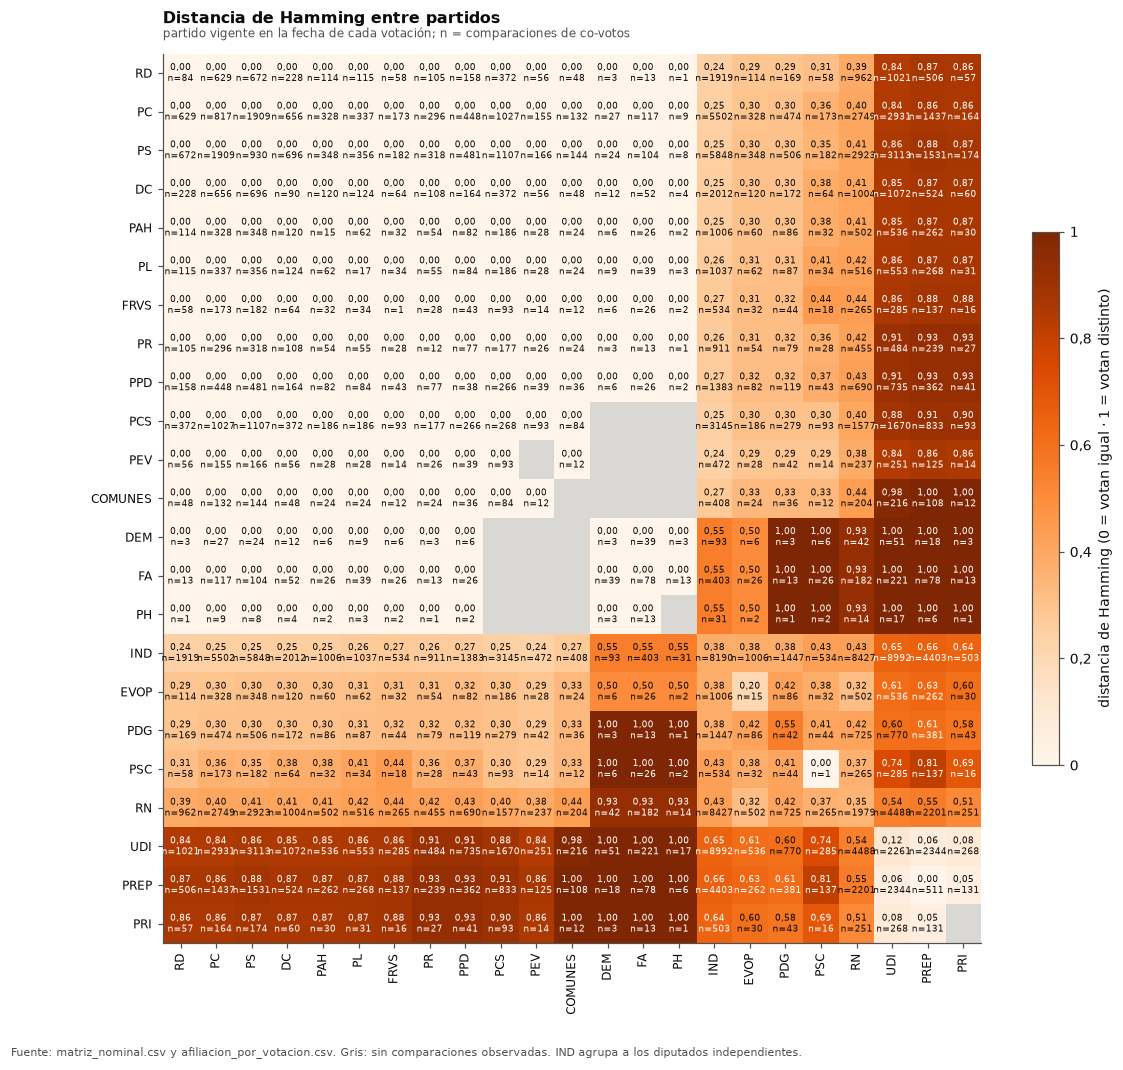

In [10]:
afiliacion = pd.read_csv(rutas['afiliacion'])
# Una comparación por par de diputados y votación con decisión de ambos; cada diputado
# cuenta para el partido vigente en esa votación (afinidad.py).
resumen_partidos = hamming_entre_partidos(cargar_matriz_nominal(rutas['nominal']), afiliacion)
publicada = pd.read_csv(rutas['hamming_partidos'])
coincide_hamming = (
    publicada[['partido_a', 'partido_b', 'n_comparaciones']]
    .equals(resumen_partidos[['partido_a', 'partido_b', 'n_comparaciones']])
    and np.allclose(publicada['hamming'], resumen_partidos['hamming'], rtol=0, atol=1e-12))
print('Coincide con hamming_partidos.csv:', coincide_hamming)
assert coincide_hamming

lista = sorted(set(resumen_partidos['partido_a']) | set(resumen_partidos['partido_b']))
distancia = pd.DataFrame(np.nan, index=lista, columns=lista)
comparaciones = pd.DataFrame(0, index=lista, columns=lista)
for fila in resumen_partidos.itertuples():
    for i, j in ((fila.partido_a, fila.partido_b), (fila.partido_b, fila.partido_a)):
        distancia.loc[i, j], comparaciones.loc[i, j] = fila.hamming, fila.n_comparaciones
orden_d = distancia.mean(axis=1, skipna=True).sort_values().index
distancia, comparaciones = distancia.loc[orden_d, orden_d], comparaciones.loc[orden_d, orden_d]

fig, ax = plt.subplots(figsize=(12, 10.5))
ax.set_facecolor(vis.SIN_DATO)
imagen = ax.imshow(np.ma.masked_invalid(distancia.to_numpy(dtype=float)), vmin=0, vmax=1,
                   cmap=vis.SECUENCIAL, aspect='auto')
for (i, j), v in np.ndenumerate(distancia.to_numpy(dtype=float)):
    if pd.notna(v):
        ax.text(j, i, f'{vis.coma(v)}\nn={comparaciones.iat[i, j]}', ha='center', va='center',
                fontsize=5.8, color='white' if v > 0.6 else vis.TEXTO)
ax.set_xticks(range(len(orden_d)), orden_d, rotation=90, fontsize=8)
ax.set_yticks(range(len(orden_d)), orden_d, fontsize=8)
barra = fig.colorbar(imagen, ax=ax, shrink=0.6,
                     label='distancia de Hamming (0 = votan igual · 1 = votan distinto)')
vis.formato_coma(barra.ax, 'y')
vis.titulo(ax, 'Distancia de Hamming entre partidos',
           'partido vigente en la fecha de cada votación; n = comparaciones de co-votos')
vis.nota(fig, 'Fuente: matriz_nominal.csv y afiliacion_por_votacion.csv. Gris: sin '
              'comparaciones observadas. IND agrupa a los diputados independientes.', y=0.02)
guardar(fig, 'matriz_hamming_partidos_historica.png')
plt.show()

### 3.4. Pares con mayor cantidad de co-votos

In [11]:
nombres = (
    votos.sort_values(["diputado_id", "fecha"])
    .drop_duplicates("diputado_id")
    .set_index("diputado_id")
)
def nombre_diputado(diputado_id):
    if diputado_id not in nombres.index:
        return str(diputado_id)
    fila = nombres.loc[diputado_id]
    partes = [
        str(fila.get("nombre", "")).strip(),
        str(fila.get("apellido_paterno", "")).strip(),
        str(fila.get("apellido_materno", "")).strip(),
    ]
    nombre = " ".join(p for p in partes if p and p.lower() != "nan")
    return f"{diputado_id} · {nombre}" if nombre else str(diputado_id)

muestra_pares = pares_validos.sort_values(
    ["n_covotos", "hamming"],
    ascending=[False, True],
).head(20).copy()

muestra_pares["diputado_i_nombre"] = muestra_pares["diputado_i"].map(nombre_diputado)
muestra_pares["diputado_j_nombre"] = muestra_pares["diputado_j"].map(nombre_diputado)

display(
    muestra_pares[
        [
            "diputado_i_nombre",
            "diputado_j_nombre",
            "n_covotos",
            "acuerdo",
            "hamming",
            "acuerdo_sin_unanimes",
            "hamming_sin_unanimes",
        ]
    ]
)

,diputado_i_nombre,diputado_j_nombre,n_covotos,acuerdo,hamming,acuerdo_sin_unanimes,hamming_sin_unanimes
376,815 · Sergio Bobadilla Muñoz,1111 · Fernando Bórquez Montecinos,15,1.0,0.0,1.0,0.0
391,815 · Sergio Bobadilla Muñoz,1126 · Felipe Donoso Castro,15,1.0,0.0,1.0,0.0
398,815 · Sergio Bobadilla Muñoz,1135 · Johannes Kaiser Barents-Von Hohenhagen,15,1.0,0.0,1.0,0.0
402,815 · Sergio Bobadilla Muñoz,1139 · Enrique Lee Flores,15,1.0,0.0,1.0,0.0
403,815 · Sergio Bobadilla Muñoz,1140 · Daniel Lilayu Vivanco,15,1.0,0.0,1.0,0.0
407,815 · Sergio Bobadilla Muñoz,1144 · Christian Matheson Villán,15,1.0,0.0,1.0,0.0
439,815 · Sergio Bobadilla Muñoz,1176 · Hotuiti Teao Drago,15,1.0,0.0,1.0,0.0
446,815 · Sergio Bobadilla Muñoz,1183 · Flor Weisse Novoa,15,1.0,0.0,1.0,0.0
599,917 · Gastón Von Mühlenbrock Zamora,976 · Juan Antonio Coloma Álamos,15,1.0,0.0,1.0,0.0
605,917 · Gastón Von Mühlenbrock Zamora,1003 · Renzo Trisotti Martínez,15,1.0,0.0,1.0,0.0


La tabla anterior prioriza pares con mayor número de co-votos para mostrar comparaciones con denominadores amplios. No se utiliza como clasificación de desempeño ni como evaluación de personas.

## 4. Sensibilidad de la posición partidaria

Se utiliza el resultado de `sensibilidad.py`. Cada escenario retira una votación y recalcula el modelo. Para evitar triplicar visualmente el mismo escenario, la figura principal usa el umbral intermedio de 60 %; los tres umbrales 40/60/80 permanecen disponibles en la tabla original.

No se define un umbral universal de “inestabilidad”. Se muestran magnitudes de cambio y cambios de publicabilidad para que la interpretación conserve el contexto del corpus.

In [12]:
sens_partidos = sensibilidad.loc[
    sensibilidad["metodo"].eq("perfil_partidario_P_p")
    & sensibilidad["unidad"].eq("partido")
].copy()

umbrales = sorted(sens_partidos["umbral_cobertura"].dropna().unique())
display(pd.Series({"umbrales_disponibles": umbrales, "filas_partidarias": len(sens_partidos)}))

sens_60 = sens_partidos.loc[
    np.isclose(sens_partidos["umbral_cobertura"].astype(float), 0.60)
].copy()

resumen_sens = (
    sens_60.groupby("id", as_index=False)
    .agg(
        max_delta_abs=("diferencia_abs", "max"),
        mediana_delta_abs=("diferencia_abs", "median"),
        cambios_signo=("cambio_signo", lambda x: int(pd.Series(x).fillna(False).astype(bool).sum())),
        cambios_publicabilidad=("cambio_publicabilidad", lambda x: int(pd.Series(x).fillna(False).astype(bool).sum())),
        escenarios=("votacion_retirada", "nunique"),
    )
)

nombres_partido = partidos.set_index("partido_id")["partido_alias"].to_dict()
resumen_sens["partido_alias"] = resumen_sens["id"].map(nombres_partido).fillna(resumen_sens["id"].astype(str))

display(resumen_sens.sort_values("max_delta_abs", ascending=False))

umbrales_disponibles    [0.4, 0.6, 0.8]
filas_partidarias                   990
dtype: object

,id,max_delta_abs,mediana_delta_abs,cambios_signo,cambios_publicabilidad,escenarios,partido_alias
3,EVOP,0.131330,0.049665,0,0,15,EVOP
20,RN,0.079308,0.017267,0,0,15,RN
10,PDG,0.060055,0.007856,1,0,15,PDG
15,PREP,0.029395,0.004748,0,0,15,PREP
21,UDI,0.019506,0.004507,0,0,15,UDI
14,PR,0.017880,0.002775,0,0,15,PR
9,PCS,0.017880,0.002775,0,0,15,PCS
19,RD,0.017880,0.002775,0,0,15,RD
6,IND,0.017850,0.002042,0,0,15,IND
1,DC,0.015441,0.004460,0,0,15,DC


### 4.1. Magnitud máxima del cambio de P_p al retirar una votación

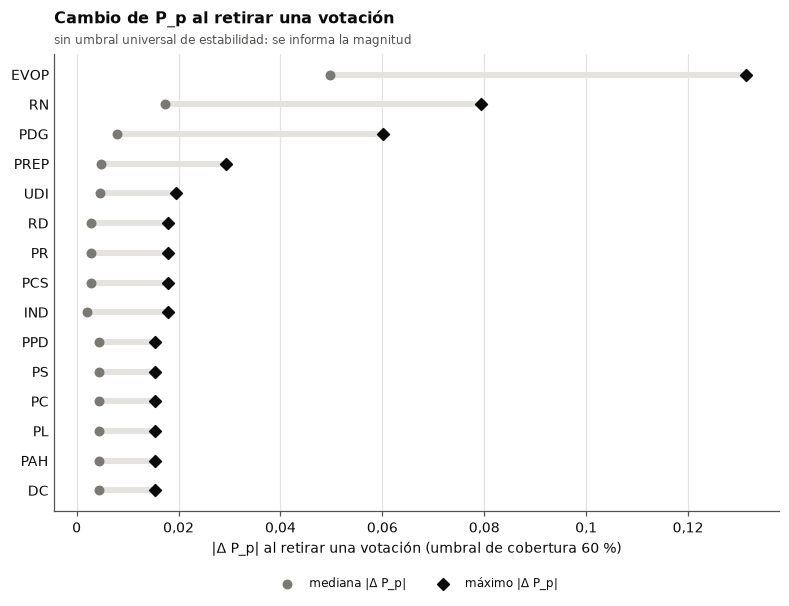

In [13]:
# Solo partidos con P_p estimable en algún escenario.
tabla_sens = resumen_sens.dropna(subset=['max_delta_abs']).sort_values('max_delta_abs')
fig, ax = plt.subplots(figsize=(8.5, max(4, 0.36 * len(tabla_sens))))
y = np.arange(len(tabla_sens))
ax.hlines(y, tabla_sens['mediana_delta_abs'], tabla_sens['max_delta_abs'],
          color=vis.GRILLA, lw=4, zorder=1)
ax.scatter(tabla_sens['mediana_delta_abs'], y, color=vis.NEUTRO, s=30, zorder=2,
           label='mediana |Δ P_p|')
ax.scatter(tabla_sens['max_delta_abs'], y, color=vis.TEXTO, marker='D', s=30, zorder=3,
           label='máximo |Δ P_p|')
ax.set_yticks(y, tabla_sens['partido_alias'])
ax.tick_params(axis='y', length=0)
ax.set_xlabel('|Δ P_p| al retirar una votación (umbral de cobertura 60 %)')
ax.grid(axis='x')
vis.formato_coma(ax, 'x')
vis.titulo(ax, 'Cambio de P_p al retirar una votación',
           'sin umbral universal de estabilidad: se informa la magnitud')
vis.leyenda_inferior(ax, ncol=2, y=-0.12)
guardar(fig, 'sensibilidad_max_pp.png')
plt.show()

### 4.2. Sensibilidad según votación retirada

,votacion_retirada,mediana_delta_abs,max_delta_abs,cambios_publicabilidad
0,20627,0.000542,0.002167,0
1,20628,0.000000,0.000000,0
2,20629,0.002521,0.038122,0
3,20630,0.002984,0.131330,0
4,20631,0.003019,0.008739,0
5,20632,0.004715,0.049665,0
6,20633,0.006151,0.048229,0
7,20634,0.005916,0.048464,0
8,20635,0.004460,0.049919,0
9,20636,0.004460,0.049919,0


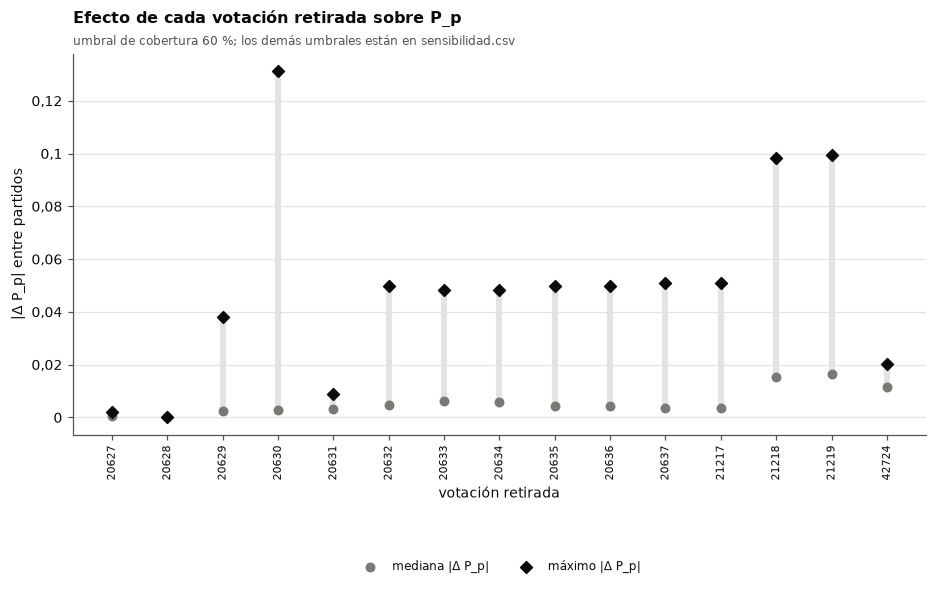

In [14]:
por_votacion = (
    sens_60.groupby('votacion_retirada', as_index=False)
    .agg(mediana_delta_abs=('diferencia_abs', 'median'),
         max_delta_abs=('diferencia_abs', 'max'),
         cambios_publicabilidad=('cambio_publicabilidad',
                                 lambda s: int(pd.Series(s).fillna(False).astype(bool).sum())))
    .sort_values('votacion_retirada'))
display(por_votacion)

fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(por_votacion))
ax.vlines(x, por_votacion['mediana_delta_abs'], por_votacion['max_delta_abs'],
          color=vis.GRILLA, lw=4, zorder=1)
ax.scatter(x, por_votacion['mediana_delta_abs'], color=vis.NEUTRO, s=30, zorder=2,
           label='mediana |Δ P_p|')
ax.scatter(x, por_votacion['max_delta_abs'], color=vis.TEXTO, marker='D', s=30, zorder=3,
           label='máximo |Δ P_p|')
ax.set_xticks(x, por_votacion['votacion_retirada'].astype(int).astype(str), rotation=90,
              fontsize=7.5)
ax.set_xlabel('votación retirada')
ax.set_ylabel('|Δ P_p| entre partidos')
ax.grid(axis='y')
vis.formato_coma(ax, 'y')
vis.titulo(ax, 'Efecto de cada votación retirada sobre P_p',
           'umbral de cobertura 60 %; los demás umbrales están en sensibilidad.csv')
vis.leyenda_inferior(ax, ncol=2, y=-0.3)
guardar(fig, 'sensibilidad_por_votacion.png')
plt.show()

## 5. Sensibilidad de la afinidad
`sensibilidad.py` retira una votación por vez y, aparte, todas las votaciones unánimes, y
recalcula dos resúmenes de la afinidad (familia `afinidad_pares` de `sensibilidad.csv`):

- **Hamming entre partidos** (sección 3.3), con el partido vigente en cada votación.
- **Mediana de Hamming entre pares de diputados** que cumplen el mínimo de co-votos, que se
  vuelve a aplicar en cada escenario.

Cerca de la mitad de los pares de partidos tiene Hamming 0 o 1 (siempre votan igual o
siempre distinto): retirar una votación no los cambia, y por eso la mediana del cambio es
casi cero. Hamming no tiene signo y no depende de los umbrales de cobertura individual, por lo que esas
columnas quedan vacías. Los pares de partidos con pocas comparaciones cambian más; por eso
la tabla conserva `n_efectivo_base`.

Valores base coinciden con hamming_partidos.csv: True


,escenario,votacion_retirada,mediana_delta_abs,max_delta_abs,pares_sin_comparaciones,delta_mediana_pares
0,retiro_una_votacion,20627,0.000000,0.067875,0,0.019048
1,retiro_una_votacion,20628,0.000000,0.067034,0,0.019048
2,retiro_una_votacion,20629,0.000000,0.057143,0,-0.035897
3,retiro_una_votacion,20630,0.000000,0.060606,0,-0.016667
4,retiro_una_votacion,20631,0.000000,0.057143,0,0.019048
5,retiro_una_votacion,20632,0.000000,0.030303,0,0.019048
6,retiro_una_votacion,20633,0.000000,0.030303,0,0.019048
7,retiro_una_votacion,20634,0.000000,0.030303,0,0.019048
8,retiro_una_votacion,20635,0.000000,0.060606,0,0.019048
9,retiro_una_votacion,20636,0.000000,0.030303,0,0.019048


,id,hamming_base,n_comparaciones,max_delta_abs
111,FRVS|PSC,0.444444,18,0.158730
193,PEV|PRI,0.857143,14,0.142857
237,PRI|RD,0.859649,57,0.140351
170,PC|PRI,0.859756,164,0.140244
198,PEV|UDI,0.840637,251,0.136214
192,PEV|PREP,0.864000,125,0.136000
169,PC|PREP,0.864301,1437,0.135699
232,PREP|RD,0.865613,506,0.134387
175,PC|UDI,0.844081,2931,0.134172
259,RD|UDI,0.843291,1021,0.134008


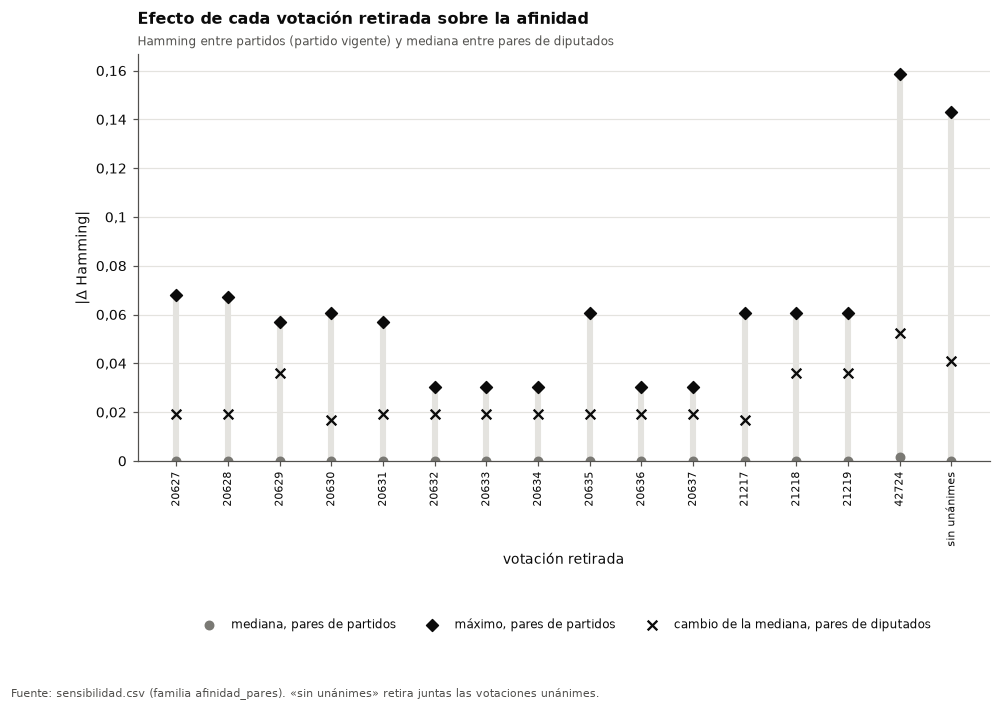

In [15]:
sens_afinidad = sensibilidad.loc[sensibilidad['familia'].eq('afinidad_pares')].copy()
sens_pares_partidos = sens_afinidad.loc[sens_afinidad['metodo'].eq('hamming_entre_partidos')]
sens_corpus = sens_afinidad.loc[sens_afinidad['metodo'].eq('mediana_hamming_pares')]

# Los valores base son la Hamming publicada en la sección 3.3.
base_afinidad = sens_pares_partidos.groupby('id')['valor_base'].first()
publicada_id = publicada.set_index(publicada['partido_a'] + '|' + publicada['partido_b'])['hamming']
coincide_base = bool(np.allclose(base_afinidad.sort_index(), publicada_id.sort_index(),
                                 rtol=0, atol=1e-12))
print('Valores base coinciden con hamming_partidos.csv:', coincide_base)
assert coincide_base

etiqueta_escenario = {'sin_votaciones_unanimes': 'sin unánimes'}
por_escenario = (
    sens_pares_partidos.groupby(['escenario', 'votacion_retirada'], as_index=False)
    .agg(mediana_delta_abs=('diferencia_abs', 'median'),
         max_delta_abs=('diferencia_abs', 'max'),
         pares_sin_comparaciones=('cambio_publicabilidad',
                                  lambda s: int(pd.Series(s).fillna(False).astype(bool).sum())))
    .merge(sens_corpus[['votacion_retirada', 'diferencia']]
           .rename(columns={'diferencia': 'delta_mediana_pares'}), on='votacion_retirada')
    .sort_values(['escenario', 'votacion_retirada']))
por_escenario['etiqueta'] = [
    etiqueta_escenario.get(e, str(v)) for e, v in
    zip(por_escenario['escenario'], por_escenario['votacion_retirada'])]
display(por_escenario.drop(columns='etiqueta'))

mas_sensibles = (
    sens_pares_partidos.groupby('id', as_index=False)
    .agg(hamming_base=('valor_base', 'first'), n_comparaciones=('n_efectivo_base', 'first'),
         max_delta_abs=('diferencia_abs', 'max'))
    .sort_values('max_delta_abs', ascending=False).head(10))
display(mas_sensibles)

fig, ax = plt.subplots(figsize=(10, 4.8))
x = np.arange(len(por_escenario))
ax.vlines(x, por_escenario['mediana_delta_abs'], por_escenario['max_delta_abs'],
          color=vis.GRILLA, lw=4, zorder=1)
ax.scatter(x, por_escenario['mediana_delta_abs'], color=vis.NEUTRO, s=30, zorder=2,
           label='mediana, pares de partidos')
ax.scatter(x, por_escenario['max_delta_abs'], color=vis.TEXTO, marker='D', s=30, zorder=3,
           label='máximo, pares de partidos')
ax.scatter(x, por_escenario['delta_mediana_pares'].abs(), color=vis.TEXTO, marker='x', s=40,
           zorder=4, label='cambio de la mediana, pares de diputados')
ax.set_xticks(x, por_escenario['etiqueta'], rotation=90, fontsize=7.5)
ax.set_xlabel('votación retirada')
ax.set_ylabel('|Δ Hamming|')
ax.set_ylim(bottom=0)
ax.grid(axis='y')
vis.formato_coma(ax, 'y')
vis.titulo(ax, 'Efecto de cada votación retirada sobre la afinidad',
           'Hamming entre partidos (partido vigente) y mediana entre pares de diputados')
vis.leyenda_inferior(ax, ncol=3, y=-0.36)
vis.nota(fig, 'Fuente: sensibilidad.csv (familia afinidad_pares). «sin unánimes» retira '
              'juntas las votaciones unánimes.', y=-0.32)
guardar(fig, 'sensibilidad_afinidad.png')
plt.show()

## 6. Reproducibilidad
Se registran el commit del repositorio, el entorno, la semilla y el corte F3 usados, y las
figuras generadas. Las tablas analíticas permanecen en `data/results` y `data/reports`;
el notebook no crea versiones rivales de esos resultados.

In [16]:
def _git(*args):
    try:
        return subprocess.run(['git', *args], cwd=raiz, capture_output=True, text=True,
                              check=True).stdout.strip()
    except (OSError, subprocess.CalledProcessError):
        return None


estado_git = _git('--no-optional-locks', 'status', '--porcelain') or ''
display(pd.Series({
    'Commit del repositorio': _git('rev-parse', 'HEAD'),
    # El propio notebook cambia al ejecutarse, por eso no cuenta como modificación.
    'Otros archivos modificados': (
        [linea for linea in estado_git.splitlines() if not linea.endswith('.ipynb')]
        or 'ninguno'),
    'Python': platform.python_version(),
    'pandas': pd.__version__,
    'matplotlib': matplotlib.__version__,
    'Commit del corte F3': manifiesto['reproducibilidad']['commit_git'],
    'Semilla (desplazamiento de puntos)': SEMILLA,
}, name='valor').to_frame())
display(pd.Series(figuras_generadas, name='figuras generadas').to_frame())
# Llegar aquí implica que todas las comprobaciones anteriores se cumplieron.
print('F4_03_APROBADO=True')

,valor
Commit del repositorio,0fd1a04d4386d025528e515cd0d0d1bfc45727b1
Otros archivos modificados,[M F4/data/reports/conciliacion_resultados.jso...
Python,3.12.13
pandas,3.0.5
matplotlib,3.11.1
Commit del corte F3,022d4d0ac3d453430e1473ac603ef5ee0ca29d9f
Semilla (desplazamiento de puntos),42


,figuras generadas
0,posicion_partidaria.png
1,posicion_partidaria_dispersion_d1.png
2,posicion_partido_votacion.png
3,afinidad_distribucion.png
4,hamming_covotos.png
5,matriz_hamming_partidos_historica.png
6,sensibilidad_max_pp.png
7,sensibilidad_por_votacion.png
8,sensibilidad_afinidad.png


F4_03_APROBADO=True


## 7. Síntesis

- La posición partidaria se reporta con su cobertura efectiva y sin convertir el eje relativo del corpus en una etiqueta política automática.
- La dispersión de `d1` se presenta como heterogeneidad descriptiva y no como cohesión.
- La afinidad entre pares conserva el número de co-votos y excluye de la comparación las celdas no observadas.
- La distancia de Hamming y el acuerdo son complementarios sobre el mismo conjunto de co-votos.
- La sensibilidad leave-one-vote-out permite identificar qué resultados cambian más cuando se retira una votación, sin imponer un umbral universal de estabilidad.
- La afinidad también se somete a retiro de votaciones: los cambios grandes se concentran en pares de partidos con pocas comparaciones.
- Los umbrales 40/60/80 se conservan como escenarios metodológicos predefinidos; no se selecciona uno a posteriori por conveniencia visual.